[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lijingwang/UConn_MODFLOW_Lab/blob/main/UConn_Forest/04_Recharge_from_Baseflow_Separation.ipynb)

# Baseflow Separation

Author: Lijing Wang (lijing.wang@uconn.edu) for ERTH 4750 at University of Connecticut

**Objective:** Separate baseflow from total streamflow and compute BFI (Baseflow Index)  

**Method:** Eckhardt (2008) recursive digital filter  
- Recession constant `a` estimated from recession periods ≥ 5 consecutive days  
- `BFI_max` calibrated via Collischonn & Fan (2013) backwards moving filter  
- Filter: `BF_i = [(1 - BFI_max)·a·BF_{i-1} + (1 - a)·BFI_max·Q_i] / (1 - a·BFI_max)`


In [1]:
import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_DIR = '/content/drive/MyDrive/MODFLOW_Lab_fenton/Fenton'
    os.chdir(DRIVE_DIR)
    print('Working directory →', os.getcwd())
else:
    print('Local: working directory →', os.getcwd())

Local: working directory → /mnt/g/My Drive/University of Connecticut/Machine Learning and Numerical Modeling in Hydrology/MODFLOW/UConn_MODFLOW_fenton/Fenton


In [2]:
! pip install dataretrieval baseflow -q

import dataretrieval.nwis as nwis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

print('Packages loaded.')

Packages loaded.


## 1. Configuration

In [3]:
SITE_ID   = '01121330'     # Fenton River near Mansfield Depot, CT
BASIN_KM2 = 89          # drainage area [km²]
START     = '2020-01-01'
END       = '2025-12-31'
PARAM_Q   = '00060'        # discharge (ft³/s)

print(f'Site      : {SITE_ID}')
print(f'Basin area: {BASIN_KM2} km²')
print(f'Period    : {START} to {END}')

Site      : 01121330
Basin area: 89 km²
Period    : 2020-01-01 to 2025-12-31


## 2. Download Daily Discharge from USGS NWIS

In [4]:
# Fetch station name dynamically
site_info, _ = nwis.get_info(sites=SITE_ID)
STATION_NAME = site_info['station_nm'].iloc[0]
print(f'Station : {STATION_NAME}')

print(f'Downloading daily discharge for site {SITE_ID} ...')
raw, _ = nwis.get_dv(sites=SITE_ID, parameterCd=PARAM_Q, start=START, end=END)

# Identify discharge column
q_col = [c for c in raw.columns if '00060' in c and 'cd' not in c][0]

raw = raw.reset_index()
raw['datetime'] = pd.to_datetime(raw['datetime'])
Q = (raw.set_index('datetime')[q_col]
        .apply(pd.to_numeric, errors='coerce')
        * 0.0283168)       # ft³/s → m³/s
Q = Q.where(Q > 0).sort_index()

# Specific discharge [mm/day]
Q_mm = Q * 86400 / (BASIN_KM2 * 1e6) * 1000

print(f'Records : {Q.notna().sum()} days')
print(f'Mean Q  : {Q.mean():.3f} m³/s  =  {Q_mm.mean():.2f} mm/day  =  {Q_mm.mean()*365:.0f} mm/yr')

Station : FENTON RIVER AT MANSFIELD, CT
Records : 2189 days
Mean Q  : 1.169 m³/s  =  1.13 mm/day  =  414 mm/yr


## 3. Eckhardt (2008) Baseflow Separation

In [5]:
from baseflow.methods import Eckhardt, LH
from baseflow.param_estimate import recession_coefficient, param_calibrate
from baseflow.comparision import strict_baseflow
from baseflow.utils import clean_streamflow

# Clean series
date_arr, Q_arr = clean_streamflow(Q)

# Step 1 — recession constant a
strict = strict_baseflow(Q_arr)
a      = recession_coefficient(Q_arr, strict)

# Step 2 — BFI_max
b_LH   = LH(Q_arr)
BFImax = param_calibrate(np.arange(0.001, 1, 0.001), Eckhardt, Q_arr, b_LH, a)

# Step 3 — Eckhardt filter
BF_arr = Eckhardt(Q_arr, b_LH, a, BFImax)
BF     = pd.Series(BF_arr, index=date_arr).reindex(Q.index)
QF     = (Q - BF).clip(lower=0)
BFI    = BF_arr.sum() / Q_arr.sum()

# Specific discharge
BF_mm = BF * 86400 / (BASIN_KM2 * 1e6) * 1000
QF_mm = QF * 86400 / (BASIN_KM2 * 1e6) * 1000

print('=== Eckhardt Filter Parameters ===')
print(f'  a       = {a:.4f}  (recession coefficient)')
print(f'  BFI_max = {BFImax:.4f}')
print(f'  BFI     = {BFI:.4f}  ({BFI*100:.1f}%)')
print()
print('=== Water Balance 2020–2025 ===')
mean_Q_mm  = Q_mm.mean()  * 365
mean_BF_mm = BF_mm.mean() * 365
mean_QF_mm = QF_mm.mean() * 365
print(f'  Total Q  = {mean_Q_mm:.0f} mm/yr')
print(f'  Baseflow = {mean_BF_mm:.0f} mm/yr')
print(f'  Quickflow= {mean_QF_mm:.0f} mm/yr')

=== Eckhardt Filter Parameters ===
  a       = 0.9684  (recession coefficient)
  BFI_max = 0.5360
  BFI     = 0.4994  (49.9%)

=== Water Balance 2020–2025 ===
  Total Q  = 414 mm/yr
  Baseflow = 207 mm/yr
  Quickflow= 207 mm/yr


## 4. Monthly Totals (2020–2025)

In [6]:
days_per_month = Q_mm.resample('MS').count()
Q_monthly  = Q_mm.resample('MS').mean()  * days_per_month
BF_monthly = BF_mm.resample('MS').mean() * days_per_month
QF_monthly = (Q_monthly - BF_monthly).clip(lower=0)
BFI_monthly = (BF_monthly / Q_monthly).round(3)

# Annual totals — use .dt.year before converting index to string
annual_bf = BF_monthly.groupby(BF_monthly.index.year).sum()

# Convert index to readable strings for display
monthly_df = pd.DataFrame({
    'Q_mm'        : Q_monthly.round(1),
    'Baseflow_mm' : BF_monthly.round(1),
    'Quickflow_mm': QF_monthly.round(1),
    'BFI'         : BFI_monthly,
})
monthly_df.index = monthly_df.index.strftime('%Y-%m')
monthly_df.index.name = 'Month'

print(monthly_df.to_string())
print(f'\nMean BFI : {BFI_monthly.mean():.3f}')
print(f'\nAnnual baseflow (mm/yr):')
for yr, val in annual_bf.items():
    print(f'  {yr}: {val:.0f} mm')

          Q_mm  Baseflow_mm  Quickflow_mm    BFI
Month                                           
2020-01   44.0         31.5          12.5  0.716
2020-02   39.1         22.0          17.1  0.562
2020-03   40.4         20.6          19.8  0.511
2020-04   60.9         29.4          31.5  0.483
2020-05   41.0         27.6          13.5  0.672
2020-06    9.0          7.4           1.6  0.824
2020-07    8.7          4.5           4.2  0.518
2020-08    2.8          1.6           1.2  0.578
2020-09    0.9          0.6           0.3  0.630
2020-10    4.6          1.3           3.3  0.279
2020-11   12.9          4.4           8.6  0.339
2020-12   69.0         23.4          45.6  0.339
2021-01   39.1         27.8          11.3  0.710
2021-02   23.8         14.5           9.4  0.607
2021-03   32.5         16.8          15.7  0.517
2021-04   33.8         17.6          16.2  0.521
2021-05   41.8         18.7          23.2  0.446
2021-06   27.7         17.0          10.7  0.615
2021-07  151.0      

## 5. Plot

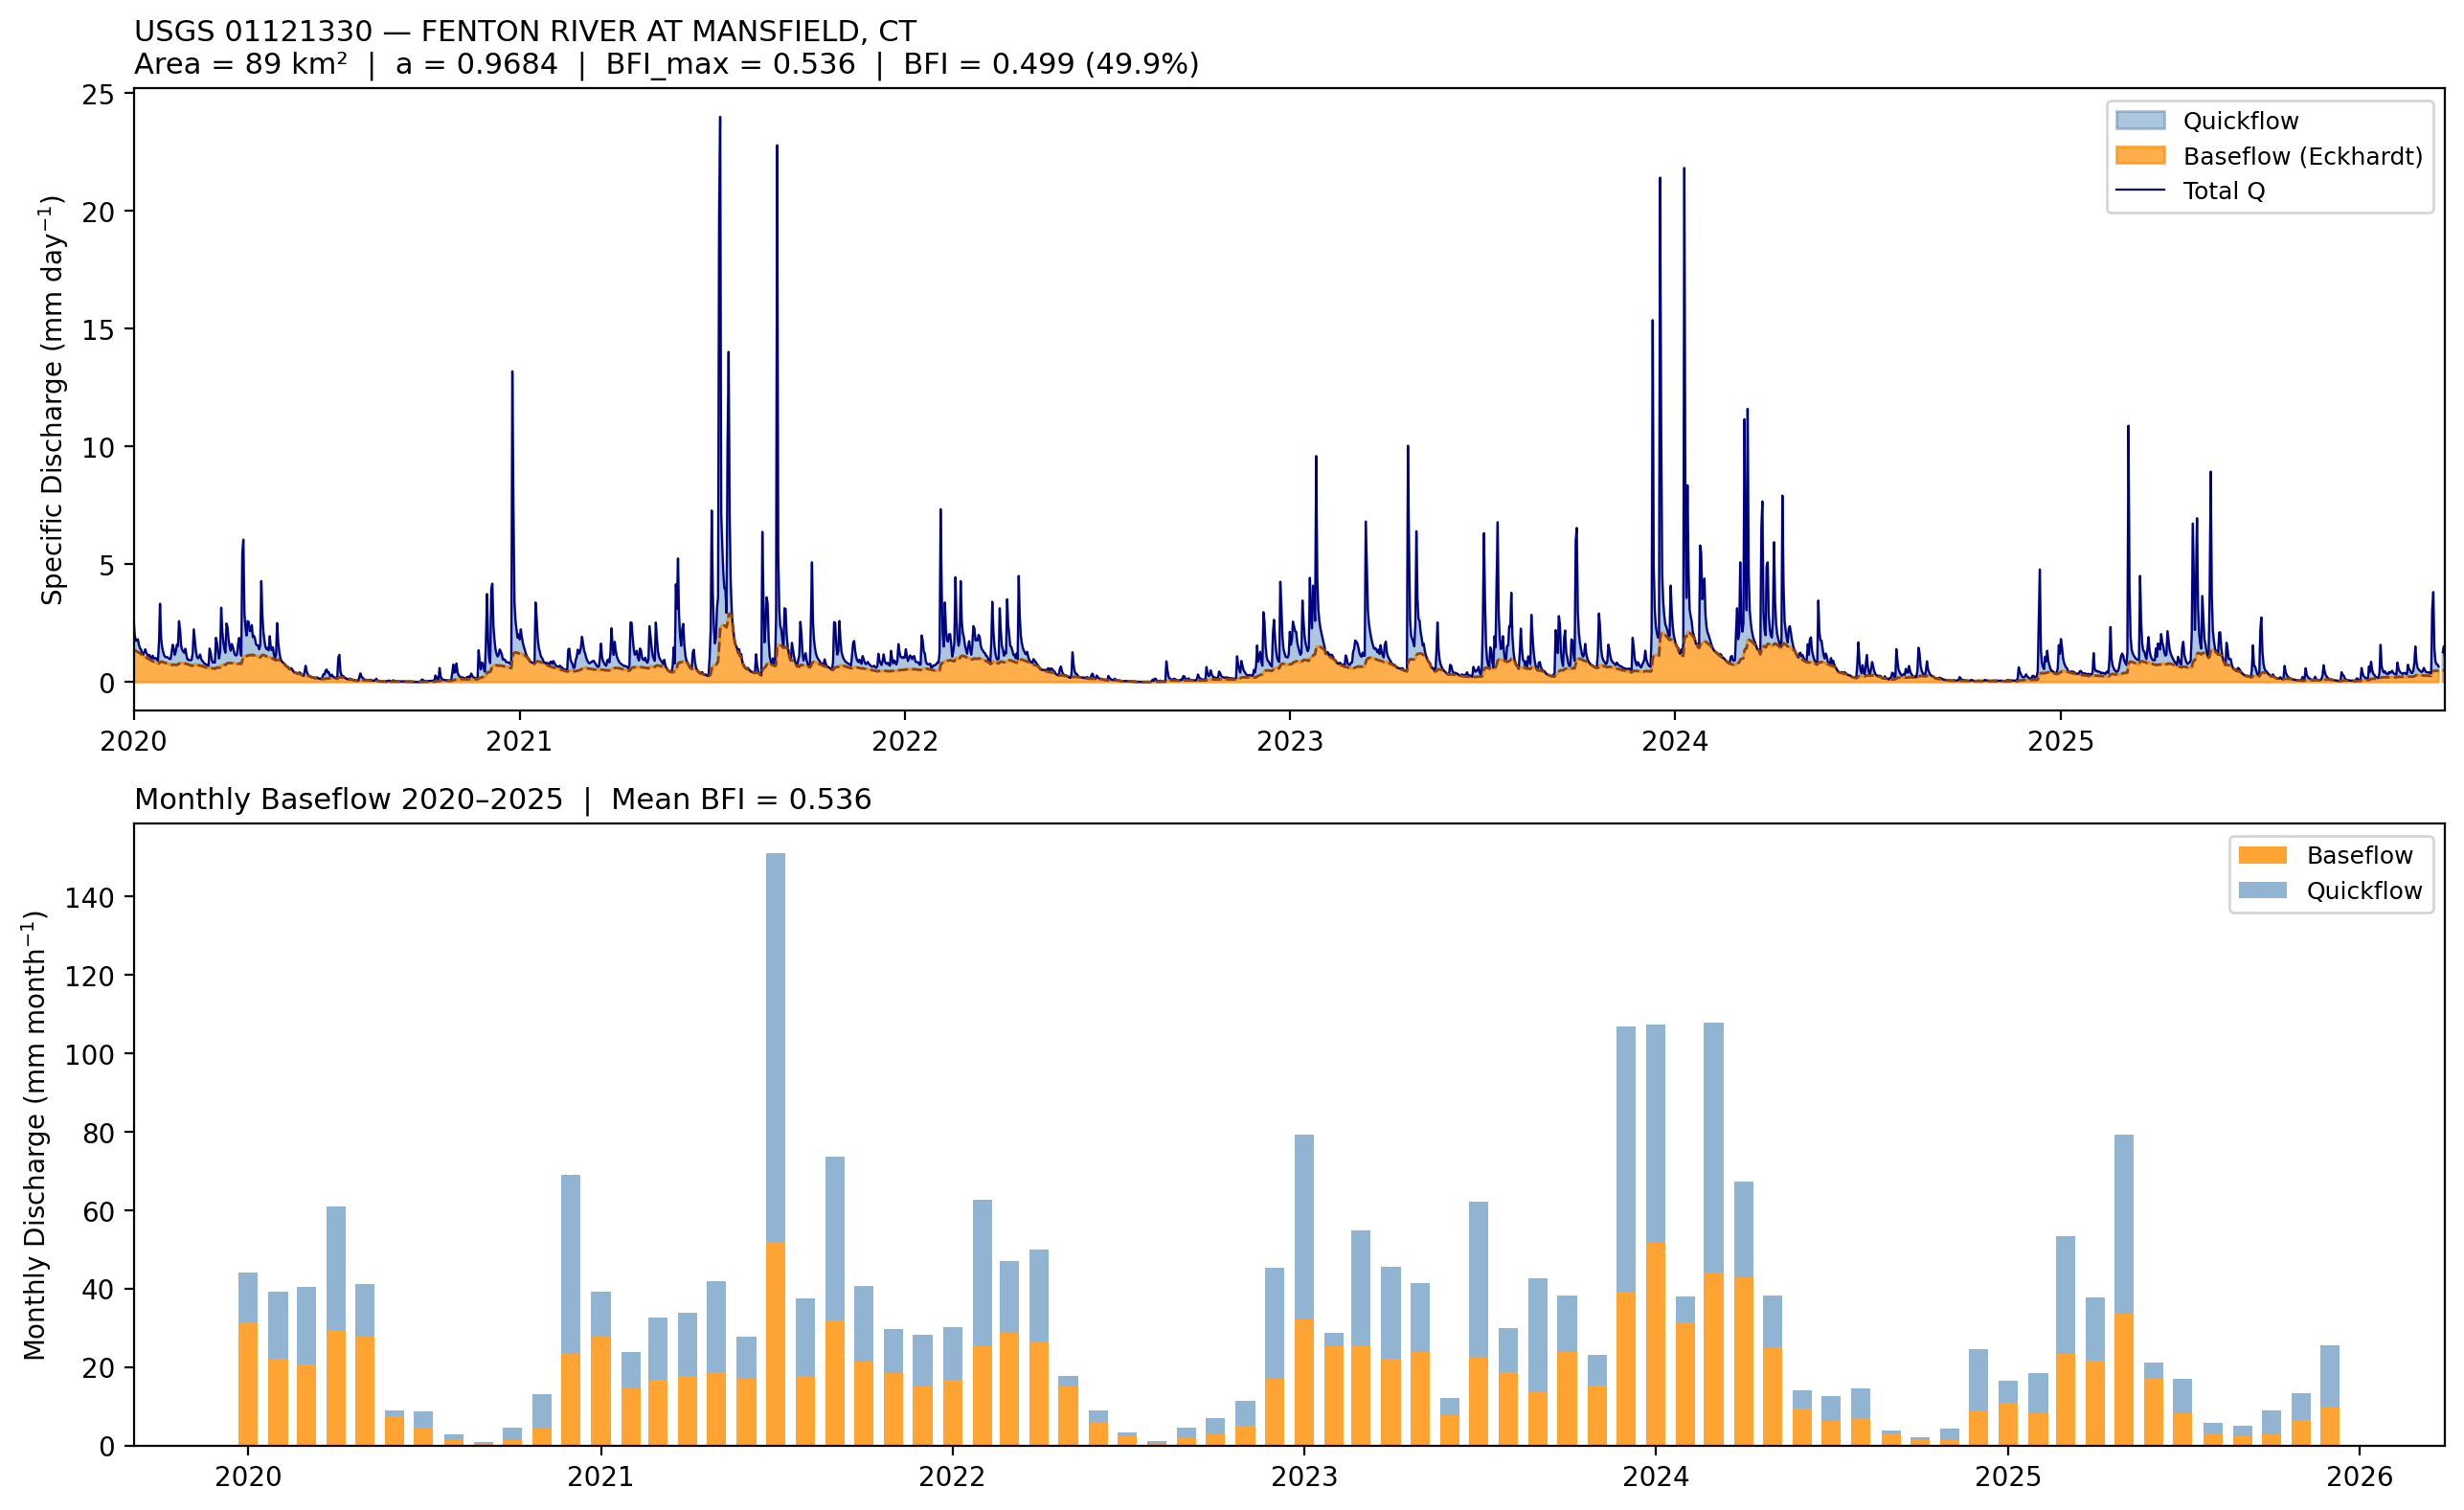

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8))

# --- Top: daily hydrograph ---
ax = axes[0]
ax.fill_between(Q_mm.index, Q_mm.values, BF_mm.values,
                color='steelblue', alpha=0.45, label='Quickflow')
ax.fill_between(BF_mm.index, BF_mm.values, 0,
                color='darkorange', alpha=0.7, label='Baseflow (Eckhardt)')
ax.plot(Q_mm.index,  Q_mm.values,  color='navy',        lw=0.8, label='Total Q')
ax.plot(BF_mm.index, BF_mm.values, color='saddlebrown', lw=1.0, ls='--')
ax.set_ylabel('Specific Discharge (mm day$^{-1}$)')
ax.set_title(
    f'USGS {SITE_ID} — {STATION_NAME}\n'
    f'Area = {BASIN_KM2} km²  |  a = {a:.4f}  |  '
    f'BFI_max = {BFImax:.3f}  |  BFI = {BFI:.3f} ({BFI*100:.1f}%)',
    fontsize=11, loc='left'
)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_xlim(Q_mm.dropna().index.min(), Q_mm.dropna().index.max())
ax.legend(fontsize=9, loc='upper right')

# --- Bottom: monthly stacked bars ---
ax2 = axes[1]
idx = pd.to_datetime(monthly_df.index)
ax2.bar(idx, monthly_df['Baseflow_mm'],  width=20, color='darkorange',
        alpha=0.8, label='Baseflow')
ax2.bar(idx, monthly_df['Quickflow_mm'], width=20, bottom=monthly_df['Baseflow_mm'],
        color='steelblue', alpha=0.6, label='Quickflow')
ax2.set_ylabel('Monthly Discharge (mm month$^{-1}$)')
ax2.set_title(
    f'Monthly Baseflow {START[:4]}–{END[:4]}  |  Mean BFI = {BFI_monthly.mean():.3f}',
    fontsize=11, loc='left'
)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('baseflow_separation.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary

In [8]:
print('=' * 50)
print(f'  BASEFLOW SEPARATION SUMMARY')
print('=' * 50)
print(f'  Site      : USGS {SITE_ID}')
print(f'  Station   : {STATION_NAME}')
print(f'  Area      : {BASIN_KM2} km²')
print(f'  Period    : {START} to {END}')
print(f'  Method    : Eckhardt (2008)')
print()
print(f'  a         : {a:.4f}')
print(f'  BFI_max   : {BFImax:.4f}')
print(f'  BFI       : {BFI:.3f}  ({BFI*100:.1f}%)')
print()
print(f'  Mean annual totals:')
print(f'    Total Q  = {mean_Q_mm:.0f} mm/yr')
print(f'    Baseflow = {mean_BF_mm:.0f} mm/yr')
print(f'    Quickflow= {mean_QF_mm:.0f} mm/yr')
print('=' * 50)

  BASEFLOW SEPARATION SUMMARY
  Site      : USGS 01121330
  Station   : FENTON RIVER AT MANSFIELD, CT
  Area      : 89 km²
  Period    : 2020-01-01 to 2025-12-31
  Method    : Eckhardt (2008)

  a         : 0.9684
  BFI_max   : 0.5360
  BFI       : 0.499  (49.9%)

  Mean annual totals:
    Total Q  = 414 mm/yr
    Baseflow = 207 mm/yr
    Quickflow= 207 mm/yr
